### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sympy.physics.control.control_plots import plt
from transformers import AutoTokenizer

from src.config import CONFIG


/Users/jackrong/University/34812-cwk-S-Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
TRAIN_DATA_PATH = Path(f'../data/train.csv')

## Task: Given a premise and a hypothesis, determine if the hypothesis is true based on the premise.

In [8]:
df = pd.read_csv(TRAIN_DATA_PATH)
df.head()

24432


Check if labels are binary:

In [4]:
n_labels = df['label'].nunique()
print(f'Number of labels: {n_labels}')

Number of labels: 2


Check data split:

In [5]:
true_count = (df['label'] == 1).sum()
false_count = (df['label'] == 0).sum()
total = df.shape[0]
print(f'Data split: {true_count / total * 100:.2f}% true, {false_count / total * 100:.2f}% false')

Data split: 51.77% true, 48.23% false


Find 95th percentile to truncate/pad token lengths to:

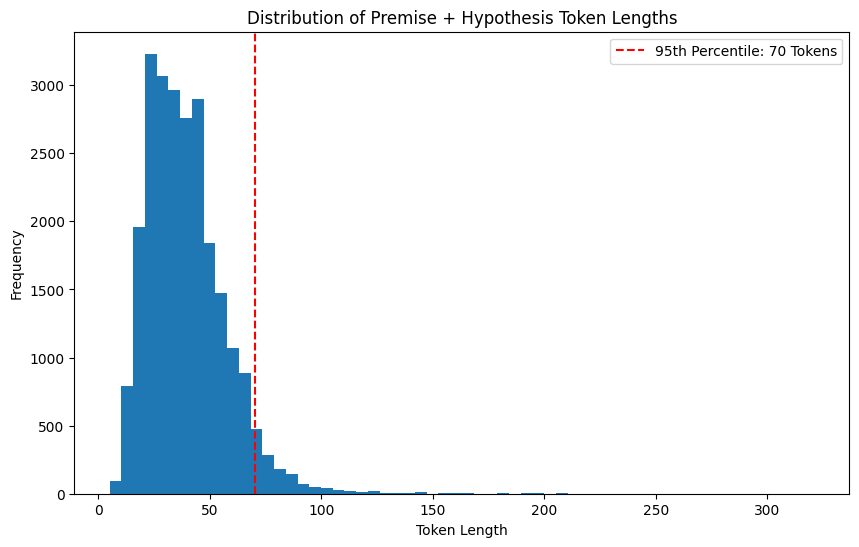

In [6]:
tokeniser = AutoTokenizer.from_pretrained(CONFIG.transformer.model)
token_lengths = df.apply(
    lambda row: len(tokeniser(row['premise'], row['hypothesis'])['input_ids']),
    axis=1
)

p95 = np.percentile(token_lengths, 95)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(token_lengths, bins=60)
ax.axvline(x=p95, color='red', linestyle='--', label=f'95th Percentile: {p95:.0f} Tokens')
ax.set_title('Distribution of Premise + Hypothesis Token Lengths')
ax.set_xlabel('Token Length')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()